<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Decision%20Tree%20Algorithms%20and%20Ensemble%20Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification

In [5]:
#1.Data Exploration and Visualization
print("--Step 1:Loading and Exploring Data---")

df = pd.read_csv('creditcard_2023.csv')
print("\nDaatset Shape",df.shape)


--Step 1:Loading and Exploring Data---

Daatset Shape (3682, 31)


In [6]:
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values per column:")
print(df.isnull().sum().sum())#Total missing values
df.dropna(inplace=True) # Drop rows with any NaN values


First 5 rows:
   id        V1        V2        V3        V4        V5        V6        V7  \
0   0 -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1   1  0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605  0.406466   
2   2 -0.260272 -0.949385  1.728538 -0.457986  0.074062  1.419481  0.743511   
3   3 -0.152152 -0.508959  1.746840 -1.090178  0.249486  1.143312  0.518269   
4   4 -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549  0.658849   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0 -0.130006  0.727159  ... -0.110552  0.217606 -0.134794  0.165959  0.126280   
1 -0.133118  0.347452  ... -0.194936 -0.605761  0.079469 -0.577395  0.190090   
2 -0.095576 -0.261297  ... -0.005020  0.702906  0.945045 -1.154666 -0.605564   
3 -0.065130 -0.205698  ... -0.146927 -0.038212 -0.214048 -1.893131  1.003963   
4 -0.212660  1.049921  ... -0.106984  0.729727 -0.161666  0.312561 -0.414116   

        V26       V27       V

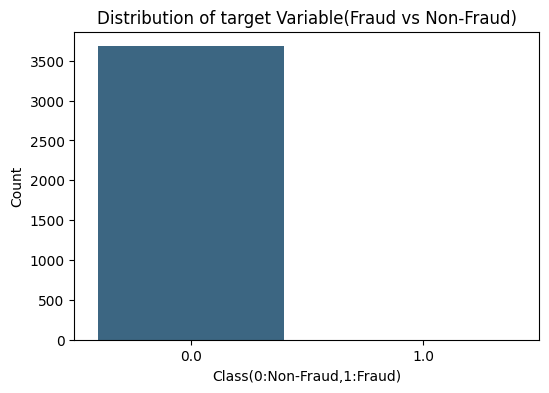

In [7]:
#Analyze the target variab;le distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class',data=df,palette='viridis')
plt.title('Distribution of target Variable(Fraud vs Non-Fraud)')
plt.xlabel('Class(0:Non-Fraud,1:Fraud)')
plt.ylabel('Count')
plt.show()

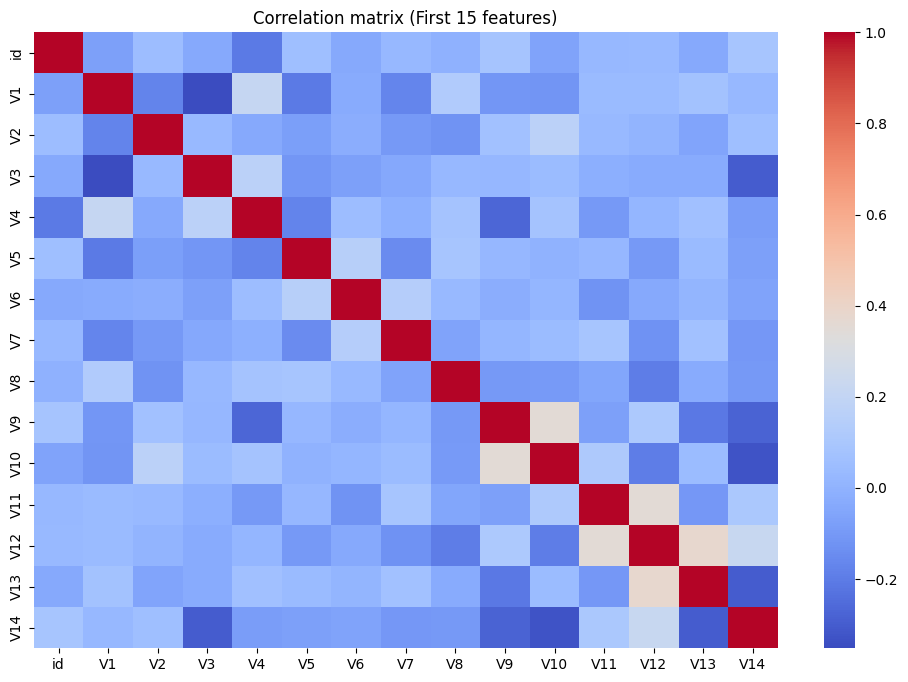

In [8]:
#Visualize relationships via a correlation matrix
plt.figure(figsize=(12,8))
#Using a subset of columns for the heatmap if the dataset
cols_to_plot = df.columns[:15]
corr_matrix = df[cols_to_plot].corr()
sns.heatmap(corr_matrix,annot=False,cmap='coolwarm',fmt=".2f")
plt.title('Correlation matrix (First 15 features)')
plt.show()

In [20]:
#Step 2:Data Pre-processing
print("\n---Step 2:Data Preprocessing---")

#Define Features (X) and target (y)

X = df.drop('Class',axis=1)
y=df['Class']

#Data Splitting(0.2) - Stratify to maintain class distribution
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Data Scaling (Crucial for KNN,Logistic Regression and ensemble methods)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape:{X_train_scaled.shape}")
print(f"Testing set shape:{X_test_scaled.shape}")

#Helper function for Model Evaluation
def evaluate_model(model,model_name,X_train,y_train,X_test,y_test):
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test,y_pred)
  prec = precision_score(y_test,y_pred,zero_division=0)
  rec = recall_score(y_test,y_pred,zero_division=0)
  f1 = f1_score(y_test,y_pred,zero_division=0)

  print(f"\n{'='*20}{model_name}{'='*20}")
  print(f"Accuracy:{acc:.4f}")
  print(f"Precision:{prec:.4f}")
  print(f"Recall:{rec:.4f}")
  print(f"F1-Score:{f1:.4f}\n")

  print("Classification Report:")
  print(classification_report(y_test,y_pred,zero_division=0))

  print("Confusion Matrix:")
  cm = confusion_matrix(y_test,y_pred)
  sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
  plt.title(f'Confusion Matrix -{model_name}')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  return {'Model':model_name,'Accuracy':acc,'Precision':prec,'Recall':rec,'F1-score':f1}

# Dictionary to store results for the final comparison table
results = []


---Step 2:Data Preprocessing---
Training set shape:(2944, 30)
Testing set shape:(737, 30)



====================Decision Tree====================
Accuracy:1.0000
Precision:0.0000
Recall:0.0000
F1-Score:0.0000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       737

    accuracy                           1.00       737
   macro avg       1.00      1.00      1.00       737
weighted avg       1.00      1.00      1.00       737

Confusion Matrix:


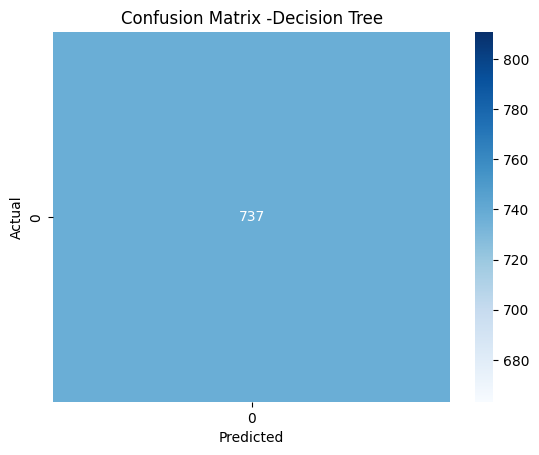

In [10]:
# Step 3: Implement Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
results.append(evaluate_model(dt_model,'Decision Tree',X_train_scaled,y_train,X_test_scaled,y_test))


====================Random Forest====================
Accuracy:1.0000
Precision:0.0000
Recall:0.0000
F1-Score:0.0000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       737

    accuracy                           1.00       737
   macro avg       1.00      1.00      1.00       737
weighted avg       1.00      1.00      1.00       737

Confusion Matrix:


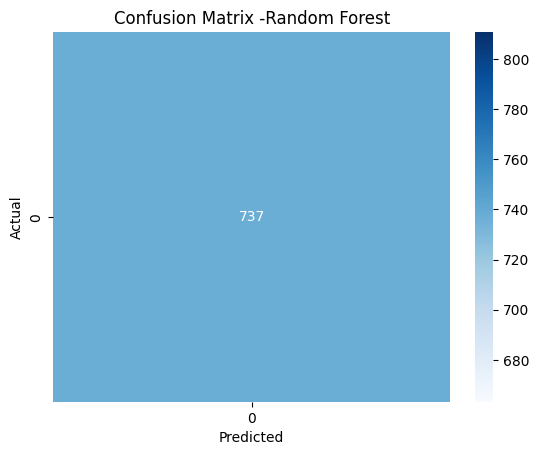

In [11]:
#Step 4:Implement Random Forest Classifier(Bagging)
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
results.append(evaluate_model(rf_model,"Random Forest",X_train_scaled,y_train,X_test_scaled,y_test))


====================Adaboost====================
Accuracy:1.0000
Precision:0.0000
Recall:0.0000
F1-Score:0.0000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       737

    accuracy                           1.00       737
   macro avg       1.00      1.00      1.00       737
weighted avg       1.00      1.00      1.00       737

Confusion Matrix:


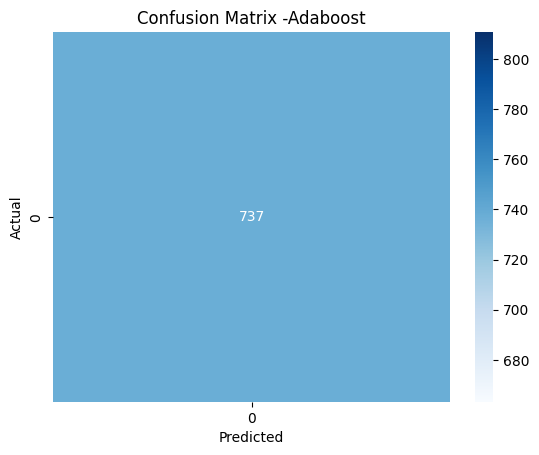

In [12]:
#Step 5: Implement Adaboost Classifier(Boosting)
ada_boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=50,learning_rate=1.0,random_state=42)
results.append(evaluate_model(ada_boost,"Adaboost",X_train_scaled,y_train,X_test_scaled,y_test))


====================Stacking====================
Accuracy:1.0000
Precision:0.0000
Recall:0.0000
F1-Score:0.0000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       737

    accuracy                           1.00       737
   macro avg       1.00      1.00      1.00       737
weighted avg       1.00      1.00      1.00       737

Confusion Matrix:


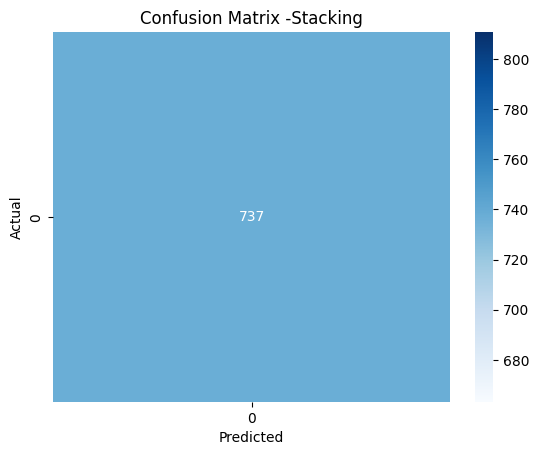

In [13]:
#Step 6:Implement Stacking Classifier
#Base Models
base_models = [('dt',DecisionTreeClassifier(random_state=42)),
               ('lr',LogisticRegression(max_iter=1000,random_state=42)),
                ('knn',KNeighborsClassifier())
                ]

#Meta Model
stacking_model = StackingClassifier(estimators=base_models,final_estimator=LogisticRegression(),cv=5)
results.append(evaluate_model(stacking_model,"Stacking",X_train_scaled,y_train,X_test_scaled,y_test))


---Step 7: Hyperparameter Tuning(Random Forest)---
Best Parameters:{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

====================Tuned Random Forest====================
Accuracy:1.0000
Precision:0.0000
Recall:0.0000
F1-Score:0.0000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       737

    accuracy                           1.00       737
   macro avg       1.00      1.00      1.00       737
weighted avg       1.00      1.00      1.00       737

Confusion Matrix:


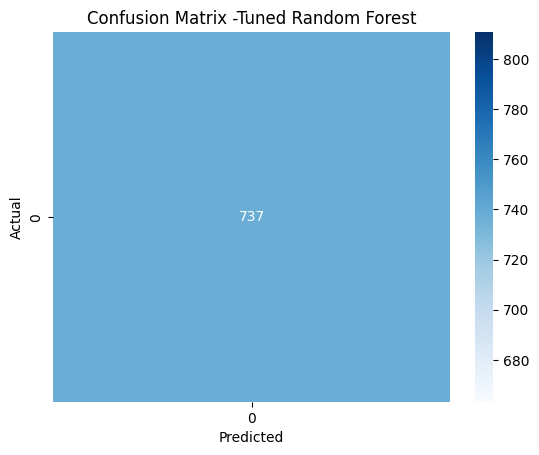

In [14]:
#Step 7: Hyperparameter Tuning
print("\n---Step 7: Hyperparameter Tuning(Random Forest)---")
param_grid = {
    'n_estimators':[50,100],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]

}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=3,scoring='f1',n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)

print(f"Best Parameters:{grid_search.best_params_}")
best_rf_model = grid_search.best_estimator_
results.append(evaluate_model(best_rf_model,"Tuned Random Forest",X_train_scaled,y_train,X_test_scaled,y_test))

In [17]:
print("\n---Step 8: Model Comparison---")
results_df = pd.DataFrame(results)
display(results_df)


---Step 8: Model Comparison---


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,1.0,0.0,0.0,0.0
1,Random Forest,1.0,0.0,0.0,0.0
2,Adaboost,1.0,0.0,0.0,0.0
3,Stacking,1.0,0.0,0.0,0.0
4,Tuned Random Forest,1.0,0.0,0.0,0.0



---Step 8:Final Model Comparison Table---
              Model  Accuracy  Precision  Recall  F1-score
      Decision Tree       1.0        0.0     0.0       0.0
      Random Forest       1.0        0.0     0.0       0.0
           Adaboost       1.0        0.0     0.0       0.0
           Stacking       1.0        0.0     0.0       0.0
Tuned Random Forest       1.0        0.0     0.0       0.0


<Figure size 1000x600 with 0 Axes>

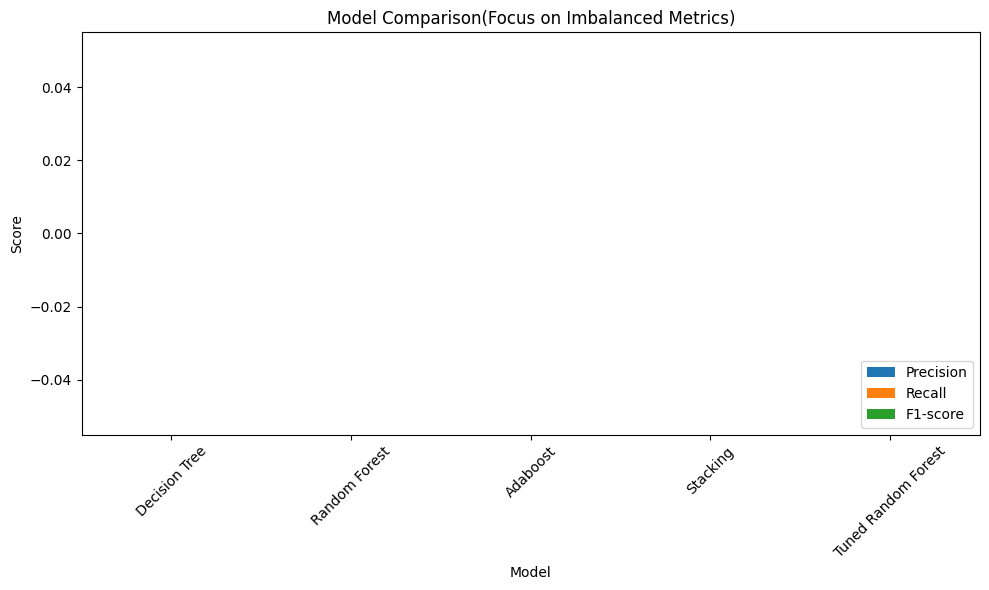


Script execution completed successfully!


In [19]:
#Step 8: Model Evaluation and Comparison
print("\n---Step 8:Final Model Comparison Table---")
comparison_df = pd.DataFrame(results)

#Formatting the dataframe to read better
comparison_df =comparison_df.round(4)
print(comparison_df.to_string(index=False))

#Visualizing the comparison
plt.figure(figsize=(10,6))
comparison_df.set_index('Model')[['Precision','Recall','F1-score']].plot(kind='bar',figsize=(10,6))
plt.title('Model Comparison(Focus on Imbalanced Metrics)')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nScript execution completed successfully!")